In [1]:
import pandas as pd
# import spacy
# from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import KeyedVectors

# Load pre-trained word vectors (Google News Word2Vec format)
# This will download ~1.5GB on first run
import gensim.downloader as api
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


/Users/momo/opt/anaconda3/lib/python3.8/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [2]:
model1 = api.load("word2vec-google-news-300")
# Load model
model2 = SentenceTransformer("all-MiniLM-L6-v2")

In [3]:
n1 = pd.read_csv("../exp_files/pilot_n.csv")
n2 = pd.read_csv("../exp_files/pilot_n2.csv")
v1 = pd.read_csv("../exp_files/pilot_v.csv")
v2 = pd.read_csv("../exp_files/pilot_v2.csv")
a1= pd.read_csv("../exp_files/pilot_a.csv")
a2 = pd.read_csv("../exp_files/pilot_a2.csv")
s = pd.read_csv("../exp_files/pilot_s.csv")

df = pd.concat([v1,v2,n1,n2,a1,a2,s])

# Get similarity with word-2-vec

In [4]:
def get_similarity(w1, w2):
    if w1 in model1 and w2 in model1:
        return model1.similarity(w1, w2)
    else:
        return None  # or 0, or np.nan
df["W2VSimilarity"] = df.apply(lambda row: get_similarity(row["Word1"], row["Word2"]), axis=1)

df.head()

,Unnamed: 0,Word1,Word2,FeatureCombo1,FeatureCombo2,FeatureMatch,W2VSimilarity
0,95,swing,slap,concrete-positive,concrete-negative,ConceptualMatchingOnly,0.159436
1,30,eat,bleed,concrete-positive,concrete-negative,ConceptualMatchingOnly,0.250918
2,158,obsess,justify,abstract-negative,abstract-positive,ConceptualMatchingOnly,0.178595
3,115,befall,believe,abstract-negative,abstract-positive,ConceptualMatchingOnly,0.140093
4,69,running,vomit,concrete-positive,concrete-negative,ConceptualMatchingOnly,0.087664


<Axes: ylabel='Density'>

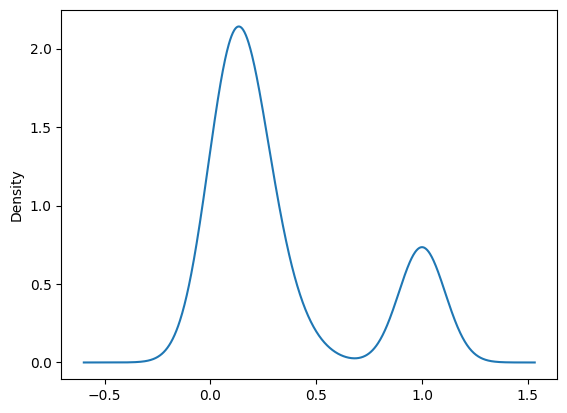

In [5]:
df["W2VSimilarity"].plot.kde()

In [6]:
df["W2VSimilarity"].isnull().values.any()

True

In [7]:
# Assuming df is your DataFrame
nan_combos = df[df["W2VSimilarity"].isna()][["Word1", "Word2"]]
print(nan_combos)

       Word1     Word2
8     poison  doughnut
16     feast  doughnut
49  doughnut   husband


# Try with BERT

In [8]:
# Compute similarities
def get_similarity(w1, w2):
    v1 = model2.encode(w1)
    v2 = model2.encode(w2)
    return cosine_similarity([v1], [v2])[0][0]

df["BertSimilarity"] = df.apply(lambda row: get_similarity(row["Word1"], row["Word2"]), axis=1)

df.head()

,Unnamed: 0,Word1,Word2,FeatureCombo1,FeatureCombo2,FeatureMatch,W2VSimilarity,BertSimilarity
0,95,swing,slap,concrete-positive,concrete-negative,ConceptualMatchingOnly,0.159436,0.366079
1,30,eat,bleed,concrete-positive,concrete-negative,ConceptualMatchingOnly,0.250918,0.268712
2,158,obsess,justify,abstract-negative,abstract-positive,ConceptualMatchingOnly,0.178595,0.294154
3,115,befall,believe,abstract-negative,abstract-positive,ConceptualMatchingOnly,0.140093,0.249459
4,69,running,vomit,concrete-positive,concrete-negative,ConceptualMatchingOnly,0.087664,0.327422


In [9]:
df.to_csv("../exp_files/total_similarity.csv")